In [1]:
# Chargement des données
import pandas as pd

df = pd.read_csv("data/idf_propre.csv")
print(f"✅ {len(df):,} transactions chargées")
print(f"\nColonnes disponibles :")
print(list(df.columns))

✅ 127,466 transactions chargées

Colonnes disponibles :
['id_mutation', 'date_mutation', 'nature_mutation', 'valeur_fonciere', 'type_local', 'surface_reelle_bati', 'nombre_pieces_principales', 'adresse_nom_voie', 'code_postal', 'nom_commune', 'code_departement', 'departement', 'longitude', 'latitude', 'prix_m2']


In [2]:
# DVF4-1 — Feature Engineering
import pandas as pd
import numpy as np

# Convertir la date
df["date_mutation"] = pd.to_datetime(df["date_mutation"])
df["mois"] = df["date_mutation"].dt.month
df["trimestre"] = df["date_mutation"].dt.quarter

# Transformer type_local en nombre (0 = Appartement, 1 = Maison)
df["est_maison"] = (df["type_local"] == "Maison").astype(int)

# Nettoyer nombre_pieces_principales — remplacer les NaN par la médiane
mediane_pieces = df["nombre_pieces_principales"].median()
df["nombre_pieces_principales"] = df["nombre_pieces_principales"].fillna(mediane_pieces)

# Variables finales pour le modèle
features = [
    "surface_reelle_bati",      # Surface en m²
    "nombre_pieces_principales", # Nombre de pièces
    "est_maison",               # Type de bien
    "departement",              # Département (numéro)
    "mois",                     # Mois de la vente
    "trimestre",                # Trimestre
    "longitude",                # Position GPS
    "latitude",
]

# Supprimer les lignes avec des NaN dans ces colonnes
df_model = df[features + ["prix_m2"]].dropna()

print(f"✅ Dataset prêt pour la modélisation")
print(f"   Lignes : {len(df_model):,}")
print(f"   Features : {len(features)}")
print(f"\nAperçu des features :")
df_model[features].head(3)

✅ Dataset prêt pour la modélisation
   Lignes : 126,439
   Features : 8

Aperçu des features :


,surface_reelle_bati,nombre_pieces_principales,est_maison,departement,mois,trimestre,longitude,latitude
0,86.0,4.0,0,75,1,1,2.405228,48.868216
1,36.0,3.0,0,75,1,1,2.347665,48.895338
2,42.0,1.0,0,75,1,1,2.370282,48.871532


In [3]:
# DVF4-2 — Split train/test + pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Séparer les features (X) de la cible (y)
X = df_model[features]
y = df_model["prix_m2"]

# Split 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42  # Pour avoir les mêmes résultats à chaque fois
)

print(f"✅ Split effectué :")
print(f"   Train : {len(X_train):,} lignes ({len(X_train)/len(X)*100:.0f}%)")
print(f"   Test  : {len(X_test):,} lignes ({len(X_test)/len(X)*100:.0f}%)")

# Créer un pipeline : normalisation + modèle
pipeline = Pipeline([
    ("scaler", StandardScaler()),  # Normalise les données
    ("model", LinearRegression())  # Modèle de base
])

print(f"\n✅ Pipeline créé :")
print(f"   Étape 1 : StandardScaler — normalise toutes les variables")
print(f"   Étape 2 : LinearRegression — modèle de régression linéaire")

✅ Split effectué :
   Train : 101,151 lignes (80%)
   Test  : 25,288 lignes (20%)

✅ Pipeline créé :
   Étape 1 : StandardScaler — normalise toutes les variables
   Étape 2 : LinearRegression — modèle de régression linéaire


In [4]:
# DVF4-3 — Régression linéaire (modèle baseline)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Entraînement
pipeline.fit(X_train, y_train)

# Prédictions sur le jeu de test
y_pred = pipeline.predict(X_test)

# Évaluation
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=== Résultats — Régression Linéaire ===")
print(f"MAE  (erreur moyenne absolue) : {mae:,.0f} €/m²")
print(f"RMSE (erreur quadratique)     : {rmse:,.0f} €/m²")
print(f"R²   (qualité du modèle)      : {r2:.3f}")

print(f"\n💡 Interprétation :")
print(f"   Le modèle se trompe en moyenne de {mae:,.0f} €/m²")
print(f"   Il explique {r2*100:.1f}% de la variance des prix")

=== Résultats — Régression Linéaire ===
MAE  (erreur moyenne absolue) : 3,444 €/m²
RMSE (erreur quadratique)     : 6,016 €/m²
R²   (qualité du modèle)      : 0.088

💡 Interprétation :
   Le modèle se trompe en moyenne de 3,444 €/m²
   Il explique 8.8% de la variance des prix


In [5]:
# Vérification XGBoost
try:
    import xgboost as xgb
    print(f"✅ XGBoost installé — version {xgb.__version__}")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "xgboost"])
    import xgboost as xgb
    print(f"✅ XGBoost installé")

✅ XGBoost installé


In [6]:
# DVF4-4 — Modèle XGBoost
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Créer et entraîner le modèle XGBoost
model_xgb = xgb.XGBRegressor(
    n_estimators=300,      # Nombre d'arbres
    max_depth=6,           # Profondeur maximale de chaque arbre
    learning_rate=0.1,     # Vitesse d'apprentissage
    subsample=0.8,         # Pourcentage de données utilisées par arbre
    colsample_bytree=0.8,  # Pourcentage de features utilisées par arbre
    random_state=42,
    n_jobs=-1              # Utilise tous les coeurs du processeur
)

print("⏳ Entraînement en cours...")
model_xgb.fit(X_train, y_train)

# Prédictions
y_pred_xgb = model_xgb.predict(X_test)

# Évaluation
mae  = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2   = r2_score(y_test, y_pred_xgb)

print("\n=== Résultats — XGBoost ===")
print(f"MAE  (erreur moyenne absolue) : {mae:,.0f} €/m²")
print(f"RMSE (erreur quadratique)     : {rmse:,.0f} €/m²")
print(f"R²   (qualité du modèle)      : {r2:.3f}")

print(f"\n💡 Interprétation :")
print(f"   Le modèle se trompe en moyenne de {mae:,.0f} €/m²")
print(f"   Il explique {r2*100:.1f}% de la variance des prix")

print(f"\n📊 Comparaison avec la régression linéaire :")
print(f"   R² baseline : 0.088  →  R² XGBoost : {r2:.3f}")

⏳ Entraînement en cours...

=== Résultats — XGBoost ===
MAE  (erreur moyenne absolue) : 2,130 €/m²
RMSE (erreur quadratique)     : 4,229 €/m²
R²   (qualité du modèle)      : 0.549

💡 Interprétation :
   Le modèle se trompe en moyenne de 2,130 €/m²
   Il explique 54.9% de la variance des prix

📊 Comparaison avec la régression linéaire :
   R² baseline : 0.088  →  R² XGBoost : 0.549


In [7]:
try:
    import shap
    print(f"✅ SHAP installé — version {shap.__version__}")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "shap"])
    import shap
    print("✅ SHAP installé")

✅ SHAP installé


⏳ Calcul des valeurs SHAP...
✅ Valeurs SHAP calculées


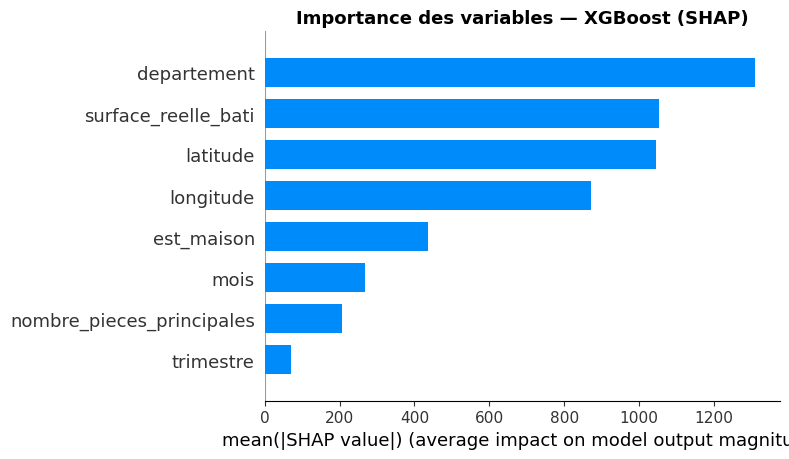

In [8]:
# DVF4-5 — Interprétabilité SHAP
import shap
import matplotlib.pyplot as plt

# Calculer les valeurs SHAP
print("⏳ Calcul des valeurs SHAP...")
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test[:2000])  # On prend 2000 lignes pour la rapidité

print("✅ Valeurs SHAP calculées")

# Graphique 1 — Importance des variables
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, 
    X_test[:2000],
    plot_type="bar",
    feature_names=features,
    show=False
)
plt.title("Importance des variables — XGBoost (SHAP)", 
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()